# 실습 4: 센서 하나로 이상 구간 찾기
- 상황: 3라인 계측 기록에서 평소와 다르게 튄 구간을 찾아본다
- 목표: 관리선을 긋고 벗어난 구간을 잡는다

## Step 1. 불러오기와 기본 확인

In [1]:
import pandas as pd

df = pd.read_csv('../../data/04_secom.csv')

# 1. 전체 행 수와 열 수
print('행 수:', df.shape[0])
print('열 수:', df.shape[1])

# 2. result 열의 값 종류별 건수와 비율
print('\nresult 값별 건수:')
print(df['result'].value_counts())

print('\nresult 값별 비율:')
print(df['result'].value_counts(normalize=True))

# 3. head()로 앞부분 확인
df.head()

행 수: 1567
열 수: 592

result 값별 건수:
result
양품    1463
불량     104
Name: count, dtype: int64

result 값별 비율:
result
양품    0.933631
불량    0.066369
Name: proportion, dtype: float64


,measured_at,sensor_001,sensor_002,sensor_003,sensor_004,sensor_005,sensor_006,sensor_007,sensor_008,sensor_009,...,sensor_582,sensor_583,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589,sensor_590,result
0,19/07/2008 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,양품
1,19/07/2008 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,양품
2,19/07/2008 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,불량
3,19/07/2008 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,양품
4,19/07/2008 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,양품


## Step 2. 관리도라는 말부터

### 용어 풀이 - 관리도 주변

| 말 | 뜻 |
|---|---|
| 관리도 | 값을 시간 순서대로 그려두고, 평소 범위를 벗어나는 순간을 잡는 그림 |
| 관리선 | 평소 범위의 경계선. 위쪽 선을 관리 상한, 아래쪽 선을 관리 하한이라 부른다 |
| 평균 | 값들을 다 더해 개수로 나눈 것. 관리도의 한가운데 선이 된다 |
| 표준편차 | 값들이 평균에서 얼마나 흩어져 있는지. 작으면 몰려 있고 크면 넓게 퍼져 있다 |
| 이상 구간 | 관리선을 벗어난 구간. 벗어났다는 것이지 곧 불량이라는 뜻은 아니다 |
| result (판정) | 검사에서 붙은 양품 또는 불량. 공정이 다 끝난 뒤에 붙는다 |
| SPC | 이런 방식으로 공정을 감시하는 것을 통틀어 부르는 말 |

## Step 3. 센서 하나 고르기

In [2]:
import pandas as pd

df = pd.read_csv('../../data/04_secom.csv')

sensor_cols = [c for c in df.columns if c.startswith('sensor_')]

# 빈칸(NaN)이 없고, 값이 실제로 변하는(종류가 2가지 이상인) 센서만 후보로 남긴다
candidates = []
for c in sensor_cols:
    s = df[c]
    if s.isna().sum() == 0 and s.nunique() > 1:
        candidates.append((c, s.nunique()))

print('조건을 만족하는 센서 개수:', len(candidates))

# 종류 수가 서로 다른 예시가 골고루 보이도록 5개를 고른다
picked = ['sensor_522', 'sensor_115', 'sensor_390', 'sensor_089', 'sensor_088']


def judge(n_unique):
    # 값 범위(넓다/좁다)는 보지 않고 오직 종류 수로만 판정
    if n_unique <= 10:
        return '정해 넣은 값에 가까움'
    elif n_unique >= 20:
        return '재고 있는 값에 가까움'
    else:
        return '확실하지 않음 (10~19가지, 애매한 구간)'


def guess_scale(min_v, max_v):
    # 자릿수만 보고 성격을 추측 — 실제 센서 의미는 알 수 없으므로 항상 '확실하지 않음'을 붙인다
    if min_v >= 0 and max_v <= 1:
        return '0~1 사이 값 → 비율일 가능성 (확실하지 않음)'
    if max_v >= 1000:
        return '네 자리 이상 큰 수 → 큰 수로 세는 값이거나 온도/전압처럼 큰 눈금일 가능성 (확실하지 않음)'
    if max_v < 1:
        return '소수점 여러 자리의 작은 값 → 아주 미세한 값일 가능성 (확실하지 않음)'
    return '수십~수백 단위 값 → 온도/전압처럼 일반적인 눈금값일 가능성 (확실하지 않음)'


rows = []
for c in picked:
    s = df[c]
    n_unique = s.nunique()
    min_v, max_v = s.min(), s.max()
    rows.append({
        '센서 이름': c,
        '값 범위 (최소~최대)': f'{min_v} ~ {max_v}',
        '값 종류 수': n_unique,
        '판정 (종류 수 기준)': judge(n_unique),
        '자릿수로 본 성격 (추정)': guess_scale(min_v, max_v),
    })

result_table = pd.DataFrame(rows)
result_table

조건을 만족하는 센서 개수: 52


,센서 이름,값 범위 (최소~최대),값 종류 수,판정 (종류 수 기준),자릿수로 본 성격 (추정)
0,sensor_522,0.0 ~ 1000.0,9,정해 넣은 값에 가까움,네 자리 이상 큰 수 → 큰 수로 세는 값이거나 온도/전압처럼 큰 눈금일 가능성 (...
1,sensor_115,0.0 ~ 0.0414,20,재고 있는 값에 가까움,0~1 사이 값 → 비율일 가능성 (확실하지 않음)
2,sensor_390,0.0001 ~ 0.3127,92,재고 있는 값에 가까움,0~1 사이 값 → 비율일 가능성 (확실하지 않음)
3,sensor_089,1627.4714 ~ 2105.1823,973,재고 있는 값에 가까움,네 자리 이상 큰 수 → 큰 수로 세는 값이거나 온도/전압처럼 큰 눈금일 가능성 (...
4,sensor_088,0.7749 ~ 0.9935,249,재고 있는 값에 가까움,0~1 사이 값 → 비율일 가능성 (확실하지 않음)


[내가 고른 열]<br>
고른 열 : [sensor_089]<br>
값 범위 : [1627.47] ~ [2105.18]   값 종류 : [973]가지<br>
값 종류가 [많으니] 이 열은 [재고 있는 값]에 가깝다<br>
AI가 본 성격 : [세 자리 이상 — 큰 수로 세는 값]

## Step 4. 평소 범위를 정하기
평균에서 표준편차 3배만큼 위아래로 관리선을 긋는다.

In [3]:
# 앞에서 고른 센서 이름을 넣는다 (본인이 고른 것으로 바꾸세요)
센서 = "sensor_089"

# 평균 — 이 센서 값들의 한가운데
평균 = df[센서].mean()

# 표준편차 — 값들이 평균에서 얼마나 흩어져 있는지
표준편차 = df[센서].std()

# 관리 상한 / 하한 — 평균에서 표준편차 3배만큼 위아래
위선 = 평균 + 3 * 표준편차
아래선 = 평균 - 3 * 표준편차

# round(값, 2) — 소수점 둘째 자리까지만 보여준다
print("평균:", round(평균, 2))
print("관리 상한:", round(위선, 2))
print("관리 하한:", round(아래선, 2))

평균: 1807.82
관리 상한: 1968.43
관리 하한: 1647.2


## Step 5. 관리도 그리기

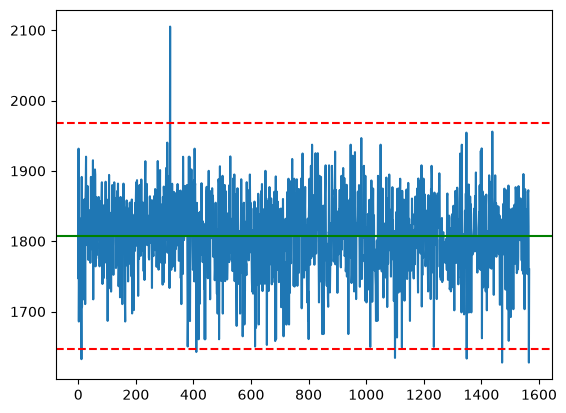

In [4]:
# 그림 그리는 도구를 plt라는 짧은 이름으로 불러온다
import matplotlib.pyplot as plt

# 센서 값을 측정 순서대로 선으로 그린다
plt.plot(df[센서])

# axhline — 가로로 쭉 뻗는 선 하나를 긋는다 (h는 horizontal, 수평)
# color는 색, linestyle="--"는 점선
plt.axhline(평균, color="green")
plt.axhline(위선, color="red", linestyle="--")
plt.axhline(아래선, color="red", linestyle="--")

# 그림을 화면에 띄운다
plt.show()

### 문법 노트 - 그림 그리기 첫걸음

| 쓴 것 | 하는 일 |
|---|---|
| plt.plot(값들) | 값을 순서대로 이어 선으로 그린다 |
| plt.axhline(높이) | 그 높이에 가로선 하나를 긋는다. 관리선이 바로 이것 |
| color="red" | 선 색을 정한다 |
| linestyle="--" | 선을 점선으로 만든다 (실선인 평균선과 구분되게) |
| plt.show() | 지금까지 얹은 것들을 한 장으로 띄운다 |
| round(값, 2) | 소수점 둘째 자리까지만 남긴다 |

**한 장의 도화지에 하나씩 얹는 방식이다.**<br>
선을 그리고, 그 위에 가로선을 세 개 얹고, 마지막에 show로 완성해서 보여준다.<br>
그래서 순서대로 쭉 쓰면 된다.

저장 위치: C:\Users\13sx0\Desktop\SECOM-PROJECT\day02\lab04_control-chart\results\sensor_089_control_chart.png
벗어난 점 개수: 7


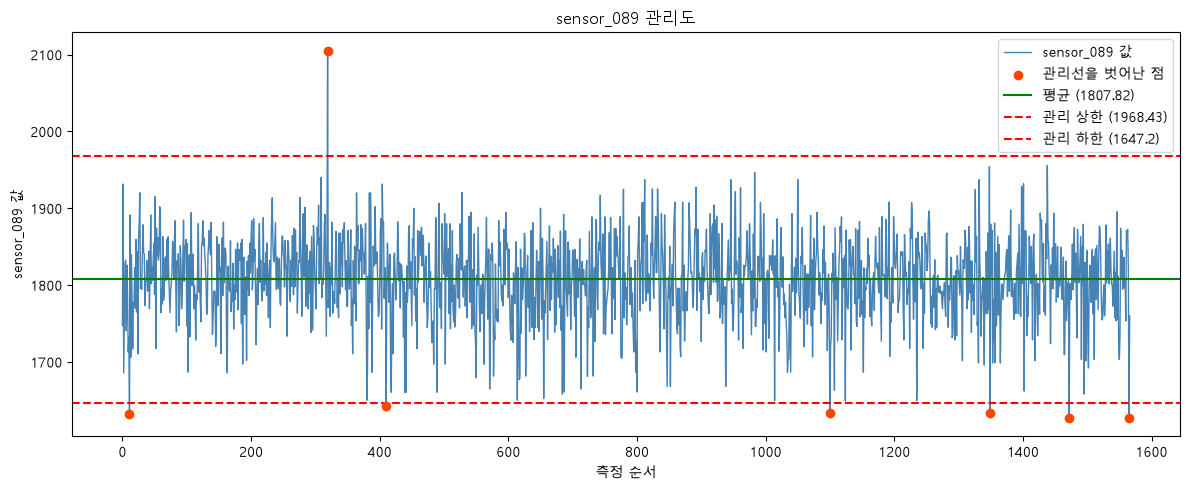

In [5]:
import os
import matplotlib.pyplot as plt

# 그래프에 한글이 네모(□)로 깨지지 않도록 한글 폰트 지정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 이 노트북이 있는 폴더 안에 results 폴더 만들기 (이미 있으면 그대로 사용)
결과_폴더 = "results"
os.makedirs(결과_폴더, exist_ok=True)

# 관리선을 벗어난 점 찾기
벗어난_점 = (df[센서] > 위선) | (df[센서] < 아래선)

fig, ax = plt.subplots(figsize=(12, 5))

# 센서 값을 측정 순서대로 선으로 그린다
ax.plot(df[센서], color="steelblue", linewidth=1, label=f"{센서} 값")

# 관리선을 벗어난 점만 다른 색으로 표시
ax.scatter(
    df.index[벗어난_점],
    df[센서][벗어난_점],
    color="orangered",
    zorder=5,
    label="관리선을 벗어난 점",
)

# 관리선 — 이름표(label)를 붙여서 범례(legend)에 나오게 한다
ax.axhline(평균, color="green", label=f"평균 ({round(평균, 2)})")
ax.axhline(위선, color="red", linestyle="--", label=f"관리 상한 ({round(위선, 2)})")
ax.axhline(아래선, color="red", linestyle="--", label=f"관리 하한 ({round(아래선, 2)})")

# 제목과 축 이름
ax.set_title(f"{센서} 관리도")
ax.set_xlabel("측정 순서")
ax.set_ylabel(f"{센서} 값")
ax.legend()

fig.tight_layout()

# 그림을 results 폴더에 저장
저장_경로 = os.path.join(결과_폴더, f"{센서}_control_chart.png")
fig.savefig(저장_경로, dpi=150)
print("저장 위치:", os.path.abspath(저장_경로))
print("벗어난 점 개수:", int(벗어난_점.sum()))

plt.show()

선을 넘은 점 : [7]개<br>
그중 관리 상한을 넘은 점 : [1]개   관리 하한 아래로 내려간 점 : [6]개

## Step 6. 선을 넘은 것이 불량이었나

In [6]:
# sensor_089가 관리 상한 또는 하한(3배 표준편차)을 벗어난 행만 골라
# 그 행들의 result 값을 세고, 전체 불량 비율과 비교한다

벗어난_행들 = df[(df[센서] > 위선) | (df[센서] < 아래선)]

건수 = 벗어난_행들['result'].value_counts()
벗어난_비율 = 벗어난_행들['result'].value_counts(normalize=True) * 100
전체_비율 = df['result'].value_counts(normalize=True) * 100

비교표 = pd.DataFrame({
    '벗어난 행 중 건수': 건수,
    '벗어난 행 중 비율(%)': 벗어난_비율.round(1),
    '전체 비율(%)': 전체_비율.round(1),
})

print('관리선을 벗어난 행 수:', len(벗어난_행들))
비교표

관리선을 벗어난 행 수: 7


,벗어난 행 중 건수,벗어난 행 중 비율(%),전체 비율(%)
result,,,
양품,6,85.7,93.4
불량,1,14.3,6.6


[Step 6 정리]<br>
관리선을 벗어난 행 : [7]개<br>
그중 result가 불량인 행 : [1]개 (벗어난 행 중 [14.3]%)<br>
전체 데이터의 불량 비율 : [6.6]%<br>
→ 벗어난 행의 불량 비율이 전체보다 [높지만], 근거가 불량 [1]건뿐이라 표본이 작아 단정하기는 [어렵다]

## Step 7. 그런데 590개는요?

센서 1개를 확인하는 데 실행한 코드 칸과 AI 요청 : [5]번<br>
590개를 다 하려면? -> 590 x [5] = [2950]번<br>
게다가 그림 590장을 하나씩 눈으로 봐야 한다.

---
## 직접 해보기 (도전) - 선을 좁히면 어떻게 될까

- 상황: 관리선을 표준편차 3배로 그었다. 이건 관행일 뿐 정답이 아니다
- 할 일: 같은 센서에 2배로 다시 그어 3배일 때와 숫자를 비교한다
- 결과물: 네 줄짜리 비교표 1개

In [7]:
# sensor_089에 대해 관리선을 두 가지 기준으로 긋고 비교한다
# 기준 A: 평균 ± 표준편차 3배 (지금까지 쓴 기준)
# 기준 B: 평균 ± 표준편차 2배 (더 좁게 잡은 기준)

전체_불량_비율 = (df['result'] == '불량').mean() * 100

기준_배수 = {
    '기준 A (3배)': 3,
    '기준 B (2배)': 2,
}

행들 = []
for 이름, 배수 in 기준_배수.items():
    관리_하한 = 평균 - 배수 * 표준편차
    관리_상한 = 평균 + 배수 * 표준편차

    벗어난 = (df[센서] < 관리_하한) | (df[센서] > 관리_상한)
    벗어난_행 = int(벗어난.sum())
    그중_불량 = int((df.loc[벗어난, 'result'] == '불량').sum())

    if 벗어난_행 > 0:
        불량_비율 = 그중_불량 / 벗어난_행 * 100
        전체_대비 = 불량_비율 / 전체_불량_비율
    else:
        불량_비율 = float('nan')
        전체_대비 = float('nan')

    행들.append({
        '기준': 이름,
        '관리 하한': round(관리_하한, 2),
        '관리 상한': round(관리_상한, 2),
        '벗어난 행 수': 벗어난_행,
        '그중 불량 수': 그중_불량,
        '불량 비율(%)': round(불량_비율, 1),
        f'전체 불량 비율({round(전체_불량_비율, 1)}%) 대비': f'{round(전체_대비, 1)}배',
    })

비교표 = pd.DataFrame(행들).set_index('기준')
비교표

,관리 하한,관리 상한,벗어난 행 수,그중 불량 수,불량 비율(%),전체 불량 비율(6.6%) 대비
기준,,,,,,
기준 A (3배),1647.20,1968.43,7,1,14.3,2.2배
기준 B (2배),1700.74,1914.89,81,5,6.2,0.9배


### 관리선 2배 vs 3배

| 항목 | 3배 | 2배 |
|---|---|---|
| 관리 상한 | [1968.4] | [1914.9] |
| 관리 하한 | [1647.2] | [1700.7] |
| 벗어난 행 수 | [7] | [81] |
| 그 행들의 불량 비율 (%) | [14.3] | [6.2] |